In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

In [2]:
df = pd.read_csv('../data/processed/rental_processed.csv')

print(df.head())
print()
print("Dataset shape:", df.shape)

        locality    area  beds  bathrooms  balconies  area_rate      rent  \
0  Goregaon East   897.0     2          2          0      134.0  120000.0   
1          Powai   490.0     1          1          0       82.0   40000.0   
2        Mundhwa   550.0     1          1          0       22.0   12000.0   
3         Hingna  1000.0     2          2          0        8.0    8000.0   
4      Mira Road   595.0     1          1          0       25.0   15000.0   

   house_type_1 BHK Flat for Rent in 7th Heaven, Dhanori, Pune  \
0                                              False             
1                                              False             
2                                              False             
3                                              False             
4                                              False             

   house_type_1 BHK Flat for Rent in Aaditya Glory II, Godhani, Nagpur  \
0                                              False              

In [3]:
with open('../models/rent_model.pkl', 'rb') as f:
    model = pickle.load(f)

print("Model loaded successfully!")

Model loaded successfully!


In [4]:
X = df.drop(columns=['rent', 'locality'])
y = df['rent']

print(X.shape)
print(y.shape)

(7691, 5480)
(7691,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(6152, 5480) (1539, 5480)


In [6]:
predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print(f"R2 Score : {r2:.4f}")
print(f"RMSE     : ₹{rmse:,.2f}")

R2 Score : 0.9642
RMSE     : ₹16,381.73


In [7]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

                                                Feature  Importance
4                                             area_rate    0.246080
0                                                  area    0.203309
5477                                   area_per_bedroom    0.133274
3233  house_type_2 BHK House for Rent in Jogeshwari ...    0.093128
5365  house_type_5 BHK Flat for Rent in Bayview Terr...    0.090270
2                                             bathrooms    0.073971
4119  house_type_3 BHK Flat for Rent in Lodha World ...    0.024162
5198  house_type_4 BHK Flat for Rent in Tahnee Heigh...    0.022499
5148  house_type_4 BHK Flat for Rent in Raiaskaran P...    0.014676
5169  house_type_4 BHK Flat for Rent in Santacruz We...    0.010180
5337  house_type_4 BHK Villa for Rent in Nandi Hills...    0.009772
5184  house_type_4 BHK Flat for Rent in Signature Is...    0.009483
3557  house_type_3 BHK Flat for Rent in 25 South, Pr...    0.006740
1                                               

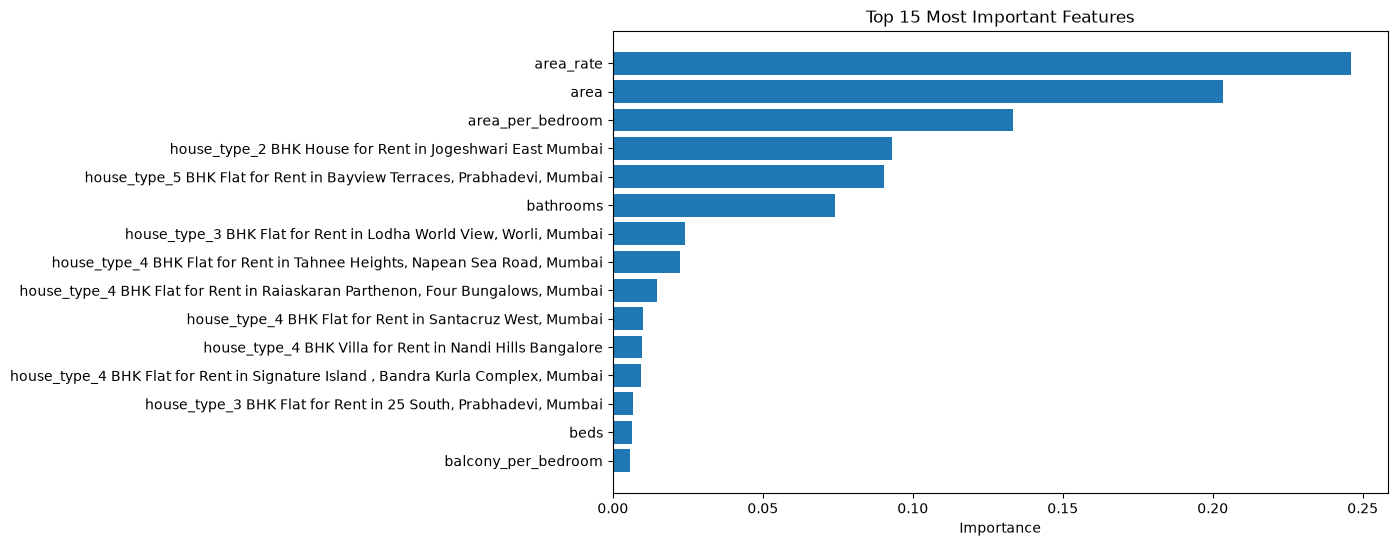

In [8]:
plt.figure(figsize=(10,6))

top_features = feature_importance.head(15)

plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()

plt.title('Top 15 Most Important Features')
plt.xlabel('Importance')

plt.show()

In [9]:
comparison = pd.DataFrame({
    'Actual Rent': y_test.values,
    'Predicted Rent': predictions
})

print(comparison.head(10))

   Actual Rent  Predicted Rent
0     240000.0   241970.281250
1      40000.0    37686.937500
2     130000.0    57032.121094
3      78000.0    79921.867188
4      80000.0    82111.437500
5     100000.0   107522.671875
6       7000.0     7182.784668
7       4000.0     4815.191895
8      32000.0    32910.296875
9      82000.0    78893.671875


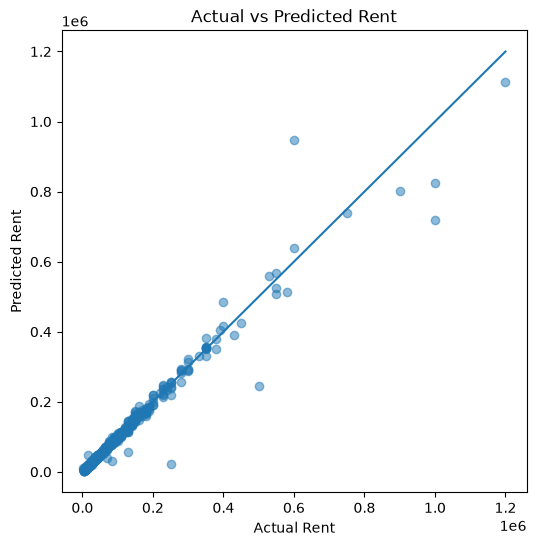

In [10]:
plt.figure(figsize=(6,6))

plt.scatter(
    comparison['Actual Rent'],
    comparison['Predicted Rent'],
    alpha=0.5
)

plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Actual vs Predicted Rent')

min_val = comparison.min().min()
max_val = comparison.max().max()

plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

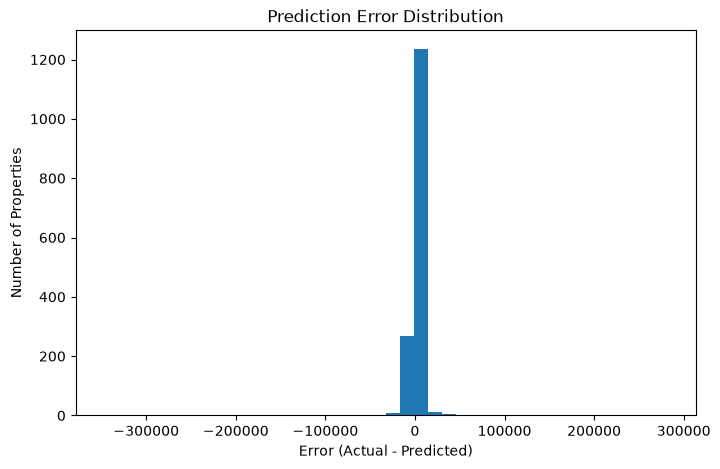

count      1539.000000
mean        486.500335
std       16379.822114
min     -347285.500000
25%        -813.108643
50%         -62.264648
75%         771.825195
max      281862.062500
dtype: float64


In [11]:
errors = comparison['Actual Rent'] - comparison['Predicted Rent']

plt.figure(figsize=(8,5))

plt.hist(errors, bins=40)

plt.title('Prediction Error Distribution')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Number of Properties')

plt.show()

print(errors.describe())

In [12]:
sample = X_test.iloc[[0]]

predicted_rent = model.predict(sample)[0]
actual_rent = y_test.iloc[0]

print("Sample Property Prediction")
print("-" * 30)
print(f"Actual Rent    : ₹{actual_rent:,.0f}")
print(f"Predicted Rent : ₹{predicted_rent:,.0f}")
print(f"Difference     : ₹{actual_rent - predicted_rent:,.0f}")
print()
print("Property Features:")
print(sample.T)

Sample Property Prediction
------------------------------
Actual Rent    : ₹240,000
Predicted Rent : ₹241,970
Difference     : ₹-1,970

Property Features:
                                 2389
area                           1300.0
beds                                3
bathrooms                           3
balconies                           2
area_rate                       185.0
...                               ...
furnishing_Semi-Furnished        True
furnishing_Unfurnished          False
area_per_bedroom           433.333333
bath_per_bedroom                  1.0
balcony_per_bedroom          0.666667

[5480 rows x 1 columns]
